# Graph Visualization & Traversal: NetworkX vs Gephi
**Dataset:** ego-Facebook (SNAP)

In [1]:
import time, gzip, os
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque, Counter
print("NetworkX", nx.__version__)

NetworkX 3.6.1


## 1. Load the data



In [2]:
DATA = "facebook_combined.txt"
try:
    from google.colab import files
    up = files.upload()                      # choose facebook_combined_txt.gz
    name = list(up.keys())[0]
    with gzip.open(name, "rb") as f_in, open(DATA, "wb") as f_out:
        f_out.write(f_in.read())
except Exception as e:
    print("Upload skipped, downloading from SNAP:", e)
    os.system("wget -q https://snap.stanford.edu/data/facebook_combined.txt.gz && gunzip -f facebook_combined.txt.gz")

G = nx.read_edgelist(DATA, nodetype=int)
print("Nodes:", G.number_of_nodes(), "| Edges:", G.number_of_edges())

Saving facebook_combined.txt.gz to facebook_combined.txt.gz
Nodes: 4039 | Edges: 88234


## 2. Graph properties and measures

In [4]:
degrees = dict(G.degree())
deg_vals = np.array(list(degrees.values()))

stats = {
    "Nodes": G.number_of_nodes(),
    "Edges": G.number_of_edges(),
    "Density": round(nx.density(G), 5),
    "Average degree": round(deg_vals.mean(), 2),
    "Max degree": deg_vals.max(),
    "Connected?": nx.is_connected(G),
    "Avg clustering coeff.": round(nx.average_clustering(G), 4),
    "Transitivity": round(nx.transitivity(G), 4),
}
# Diameter / avg path length via sampling (exact is slow on 4k nodes)
stats["Diameter (exact)"] = nx.diameter(G)
stats["Avg shortest path (exact)"] = round(nx.average_shortest_path_length(G), 3)
pd.Series(stats)

,0
Nodes,4039
Edges,88234
Density,0.01082
Average degree,43.69
Max degree,1045
Connected?,True
Avg clustering coeff.,0.6055
Transitivity,0.5192
Diameter (exact),8
Avg shortest path (exact),3.693


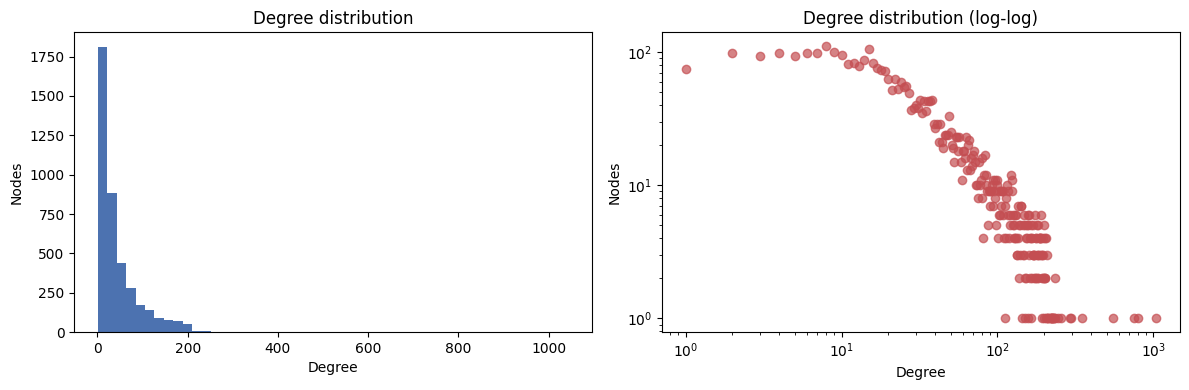

Top 10 hubs (node, degree): [(107, 1045), (1684, 792), (1912, 755), (3437, 547), (0, 347), (2543, 294), (2347, 291), (1888, 254), (1800, 245), (1663, 235)]


In [5]:
# Degree distribution (linear + log-log)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(deg_vals, bins=50, color="#4C72B0")
ax[0].set_title("Degree distribution"); ax[0].set_xlabel("Degree"); ax[0].set_ylabel("Nodes")
cnt = Counter(deg_vals)
x, y = zip(*sorted(cnt.items()))
ax[1].loglog(x, y, "o", color="#C44E52", alpha=0.7)
ax[1].set_title("Degree distribution (log-log)"); ax[1].set_xlabel("Degree"); ax[1].set_ylabel("Nodes")
plt.tight_layout(); plt.savefig("degree_distribution.png", dpi=200); plt.show()

top = sorted(degrees.items(), key=lambda t: t[1], reverse=True)[:10]
print("Top 10 hubs (node, degree):", top)

## 3. Graph traversal: BFS vs DFS


In [6]:
source = max(degrees, key=degrees.get)
print("Source node:", source, "| degree:", degrees[source])

# ---- BFS (manual implementation, with levels) ----
def bfs_levels(G, s):
    level = {s: 0}; order = []; q = deque([s])
    while q:
        u = q.popleft(); order.append(u)
        for v in G[u]:
            if v not in level:
                level[v] = level[u] + 1; q.append(v)
    return order, level

# ---- DFS (iterative, with depth) ----
def dfs_depth(G, s):
    depth = {s: 0}; order = []; stack = [(s, iter(G[s]))]; order.append(s)
    while stack:
        u, it = stack[-1]
        for v in it:
            if v not in depth:
                depth[v] = depth[u] + 1; order.append(v)
                stack.append((v, iter(G[v]))); break
        else:
            stack.pop()
    return order, depth

t0 = time.perf_counter(); bfs_order, bfs_lvl = bfs_levels(G, source); t_bfs = time.perf_counter() - t0
t0 = time.perf_counter(); dfs_order, dfs_dep = dfs_depth(G, source); t_dfs = time.perf_counter() - t0

print(f"BFS visited {len(bfs_order)} nodes in {t_bfs*1000:.2f} ms | max depth {max(bfs_lvl.values())}")
print(f"DFS visited {len(dfs_order)} nodes in {t_dfs*1000:.2f} ms | max depth {max(dfs_dep.values())}")
print("First 15 nodes, BFS:", bfs_order[:15])
print("First 15 nodes, DFS:", dfs_order[:15])

# Sanity check against NetworkX built-ins
assert set(bfs_order) == set(nx.bfs_tree(G, source).nodes())
assert bfs_lvl == nx.single_source_shortest_path_length(G, source)
print("Manual BFS matches NetworkX: OK")

Source node: 107 | degree: 1045
BFS visited 4039 nodes in 21.50 ms | max depth 5
DFS visited 4039 nodes in 30.40 ms | max depth 1961
First 15 nodes, BFS: [107, 0, 58, 171, 348, 353, 363, 366, 376, 389, 414, 420, 428, 475, 483]
First 15 nodes, DFS: [107, 0, 1, 48, 30, 9, 3, 25, 21, 13, 26, 40, 29, 16, 82]
Manual BFS matches NetworkX: OK


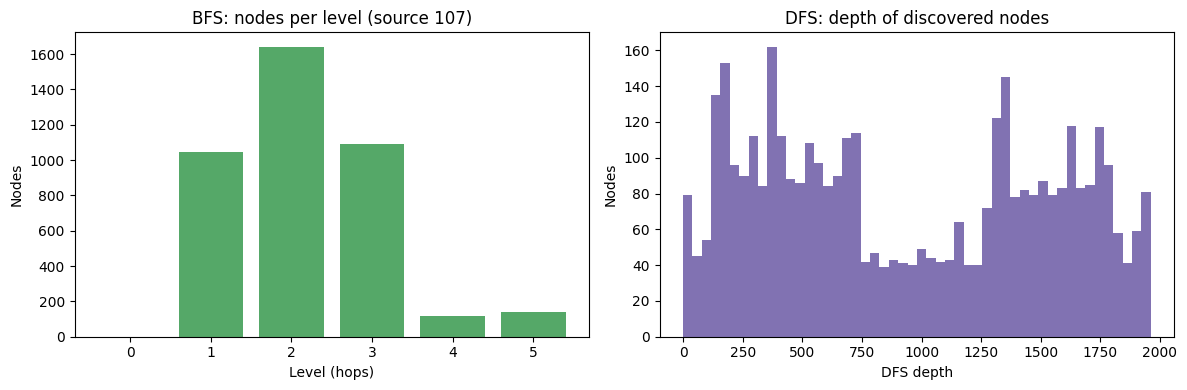

BFS shortest path 107 -> 855: 5 hops
Depth DFS assigned to the same target: 253 (much longer, not a shortest path)


In [7]:
# BFS reach per level vs DFS depth profile
lvl_counts = Counter(bfs_lvl.values())
dep_counts = Counter(dfs_dep.values())
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(lvl_counts.keys(), lvl_counts.values(), color="#55A868")
ax[0].set_title(f"BFS: nodes per level (source {source})"); ax[0].set_xlabel("Level (hops)"); ax[0].set_ylabel("Nodes")
ax[1].hist(list(dfs_dep.values()), bins=50, color="#8172B2")
ax[1].set_title("DFS: depth of discovered nodes"); ax[1].set_xlabel("DFS depth"); ax[1].set_ylabel("Nodes")
plt.tight_layout(); plt.savefig("bfs_dfs_profile.png", dpi=200); plt.show()

# Shortest path example (BFS gives true shortest paths, DFS does not)
target = bfs_order[-1]
sp = nx.shortest_path(G, source, target)
print(f"BFS shortest path {source} -> {target}: {len(sp)-1} hops")
print("Depth DFS assigned to the same target:", dfs_dep[target], "(much longer, not a shortest path)")

## 4. NetworkX visualization

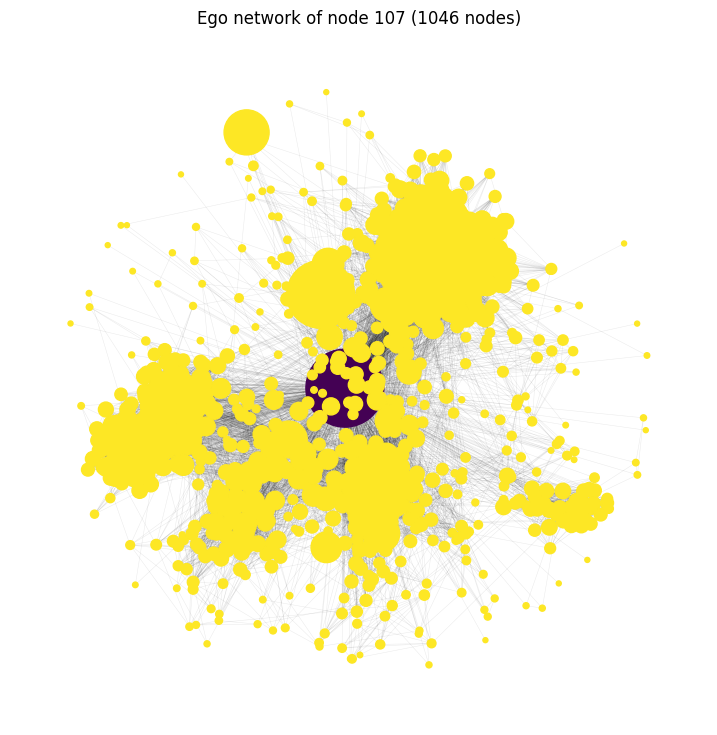

In [8]:
# (a) Ego network of the source node, colored by BFS level
ego = nx.ego_graph(G, source, radius=1)
pos = nx.spring_layout(ego, seed=42, k=0.15)
plt.figure(figsize=(9, 9))
nx.draw_networkx_edges(ego, pos, alpha=0.08, width=0.4)
nx.draw_networkx_nodes(ego, pos, node_size=[10 + 3*degrees[n] for n in ego],
                       node_color=[bfs_lvl[n] for n in ego], cmap="viridis")
plt.title(f"Ego network of node {source} ({ego.number_of_nodes()} nodes)"); plt.axis("off")
plt.savefig("networkx_ego.png", dpi=200, bbox_inches="tight"); plt.show()

Spring layout time: 82.8 s


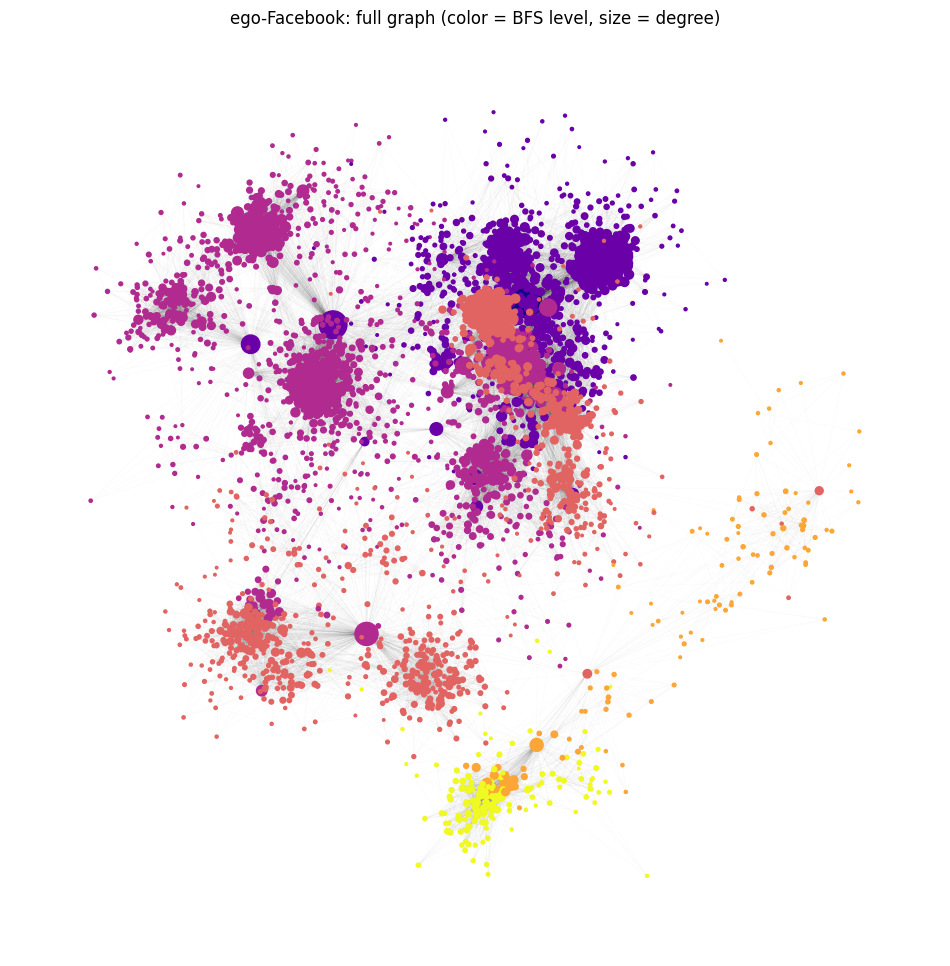

In [9]:
# (b) Full graph, colored by BFS level, sized by degree  (takes about 1-3 minutes)
t0 = time.perf_counter()
pos_full = nx.spring_layout(G, seed=42, iterations=50)
t_layout = time.perf_counter() - t0
print(f"Spring layout time: {t_layout:.1f} s")

plt.figure(figsize=(12, 12))
nx.draw_networkx_edges(G, pos_full, alpha=0.03, width=0.3)
nx.draw_networkx_nodes(G, pos_full, node_size=[3 + 0.5*degrees[n] for n in G],
                       node_color=[bfs_lvl[n] for n in G], cmap="plasma")
plt.title("ego-Facebook: full graph (color = BFS level, size = degree)"); plt.axis("off")
plt.savefig("networkx_full.png", dpi=200, bbox_inches="tight"); plt.show()

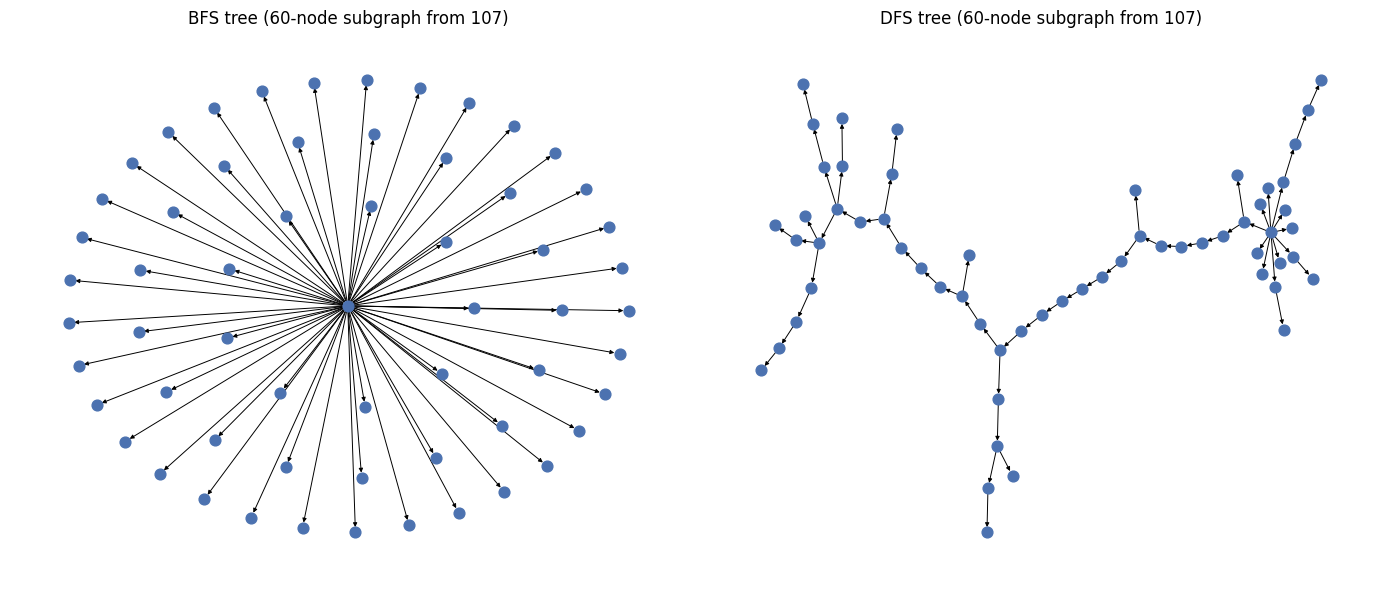

In [10]:
# (c) BFS tree vs DFS tree on a small subgraph (easy to read in the report)
sub_nodes = bfs_order[:60]
H = G.subgraph(sub_nodes)
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
for a, (name, T) in zip(ax, [("BFS tree", nx.bfs_tree(H, source)), ("DFS tree", nx.dfs_tree(H, source))]):
    p = nx.kamada_kawai_layout(T.to_undirected())
    nx.draw(T, p, ax=a, node_size=60, node_color="#4C72B0", arrowsize=6, width=0.7)
    a.set_title(f"{name} (60-node subgraph from {source})")
plt.tight_layout(); plt.savefig("bfs_vs_dfs_trees.png", dpi=200); plt.show()

## 5. Export for Gephi


In [11]:
t0 = time.perf_counter()
comms = nx.community.louvain_communities(G, seed=42)
t_comm = time.perf_counter() - t0
comm_of = {n: i for i, c in enumerate(comms) for n in c}
pr = nx.pagerank(G)
print("Louvain communities:", len(comms), "| modularity:",
      round(nx.community.modularity(G, comms), 4), f"| {t_comm:.1f}s")

for n in G.nodes():
    G.nodes[n]["degree"] = int(degrees[n])
    G.nodes[n]["bfs_level"] = int(bfs_lvl[n])
    G.nodes[n]["dfs_depth"] = int(dfs_dep[n])
    G.nodes[n]["community"] = int(comm_of[n])
    G.nodes[n]["pagerank"] = float(pr[n])
    G.nodes[n]["label"] = str(n)

nx.write_gexf(G, "facebook_graph.gexf")
print("Saved facebook_graph.gexf")

try:
    from google.colab import files
    for f in ["facebook_graph.gexf", "degree_distribution.png", "bfs_dfs_profile.png",
              "networkx_ego.png", "networkx_full.png", "bfs_vs_dfs_trees.png"]:
        files.download(f)
except Exception:
    pass

Louvain communities: 16 | modularity: 0.8349 | 1.9s
Saved facebook_graph.gexf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>